#**Detecting Fake Reviews with Attention**





#*An Attention Layer from Scratch*

Let's try another approach to deciding which words are more or less important in a sequence, depending on the context of all words seen. We are going to implement a hard-coded attention mechanism here, from scratch.

Let's reimport and process our dataset as before.

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from google.colab import files
import pandas as pd
import io
import numpy as np

from google.colab import drive

drive.mount('/content/drive')
reviews = pd.read_csv("/content/drive/MyDrive/Teaching/Courses/BA 510/Course Material/Week 8/dataset/fake reviews dataset.csv")

label = np.where(reviews['label']=='CG',1,0)
reviews = np.array(reviews['text_'])

print(reviews[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty


Let's make a TextVectorization() layer to preprocess our text.

In [12]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=20000,
    output_mode="int", # This is requesting multihot encodings (which means we'll have a fixed vector of 1's and 0's per review)
)

text_vectorization.adapt(reviews)

We are going to start off with one-hot encodings again, just to make sure we understand the shapes of all the tensors and things as we go along, so we understand what the network is doing!

In [14]:
processed_text = text_vectorization(reviews)

# We have 40,432 reviews, with sequences up to 373 words in length.
print(processed_text.shape)

(40432, 373)


Now we can make our network... notice that we have extremely few trainable weights in here... only the final dense layer has any weights!

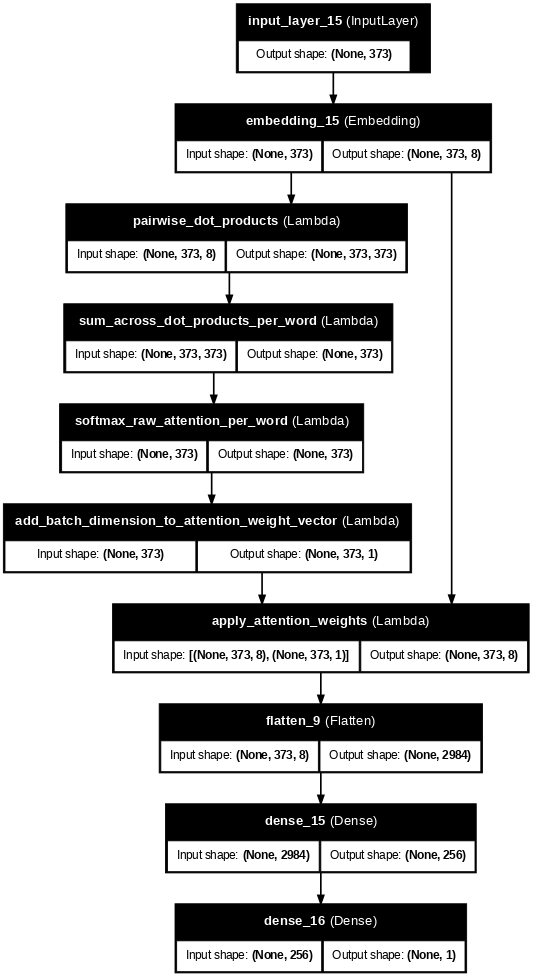

In [54]:
from keras.layers import Flatten, Activation, RepeatVector, Permute, Multiply, Lambda, Dense


# Now, let's start specifying our model...
inputs = keras.layers.Input(shape=[373,]) # We take the sequence of intger encodings as input.

embeds = keras.layers.Embedding(input_dim=20000,output_dim=8)(inputs) # Map integers to 8-dimensional vectors.

# 1. Calculate dot products between all pairs of word embeddings
dot_products = Lambda(lambda x: tf.matmul(x, x, transpose_b=True),name="pairwise_dot_products")(embeds)  # (batch_size, seq_len, seq_len)

# 2. Sum dot products for each word to get attention scores
attention_scores = Lambda(lambda x: tf.reduce_sum(x, axis=-1),name="sum_across_dot_products_per_word")(dot_products)  # (batch_size, seq_len)

# 3. Apply softmax to normalize attention scores
attention_weights = Lambda(lambda x: tf.nn.softmax(x, axis=-1),name="softmax_raw_attention_per_word")(attention_scores)  # (batch_size, seq_len)

# 4. Reshape attention weights for broadcasting
attention_weights = Lambda(lambda x: tf.expand_dims(x, axis=-1),name="add_batch_dimension_to_attention_weight_vector")(attention_weights)  # (batch_size, seq_len, 1)

# 5. Per focal word (embedding), multiply each embedding in the sequence by its attention weight, then sum all the weighted embeddings together to get the adjusted embedding for the focal word.
# We do this in parallel for each word in the sequence, shifting / adjusting the embedding vector 'toward' the most relevant *other* words in the seqeunce.
attention_output = Lambda(lambda x: x[0] * x[1],name="apply_attention_weights")([embeds, attention_weights])  # (batch_size, seq_len, embedding_dim)

flatten = layers.Flatten()(attention_output)

hidden = keras.layers.Dense(256, activation="sigmoid")(flatten)

outputs = keras.layers.Dense(1, activation="sigmoid")(hidden)

model = keras.Model(inputs,outputs)
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model,show_shapes=True,dpi=60,show_layer_names=True)

How many trainable parameters are in this NN? 325k or so. And they are all in the embedding layer and final dense layer.

In [55]:
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 373)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 373, 8)    │    160,000 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pairwise_dot_produ… │ (None, 373, 373)  │          0 │ embedding_15[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_across_dot_pro… │ (None, 373)       │          0 │ pairwise_dot_pro… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_raw_attent… │ (None, 373)       │          0 │ sum_across_dot_p… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_batch_dimensio… │ (None, 373, 1)    │          0 │ softmax_raw_atte… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_attention_we… │ (None, 373, 8)    │          0 │ embedding_15[0][… │
│ (Lambda)            │                   │            │ add_batch_dimens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 2984)      │          0 │ apply_attention_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │    764,160 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │        257 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 924,417 (3.53 MB)

 Trainable params: 924,417 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

And, let's try fitting this model... our hard-coded attention mechanism does quite well!

In [56]:
callbacks = [
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/Teaching/Courses/BA 510/Course Material/Week 8/attention_from_scratch.keras",
                                    save_best_only=True)
]

history = model.fit(processed_text, label,
                        validation_split=0.2,
                        epochs=20, batch_size=32,callbacks=callbacks)

Epoch 1/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6941 - loss: 0.5689 - val_accuracy: 0.7068 - val_loss: 0.5346
Epoch 2/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8330 - loss: 0.3727 - val_accuracy: 0.7379 - val_loss: 0.4841
Epoch 3/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8594 - loss: 0.3298 - val_accuracy: 0.8164 - val_loss: 0.4139
Epoch 4/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8309 - loss: 0.3636 - val_accuracy: 0.8213 - val_loss: 0.4124
Epoch 5/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8773 - loss: 0.3001 - val_accuracy: 0.8094 - val_loss: 0.4002
Epoch 6/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9008 - loss: 0.2499 - val_accuracy: 0.7256 - val_loss: 0.7413
Epoch 7/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9017 - loss: 0.2485 - val_accuracy: 0.8328 - val_loss: 0.4118
Epoch 8/20
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9144 - loss: 0.2182 - 

And, plotting model performance, as well as evaluating against the test set, what do we get... our best model yields about 87% accuracy in the test data.

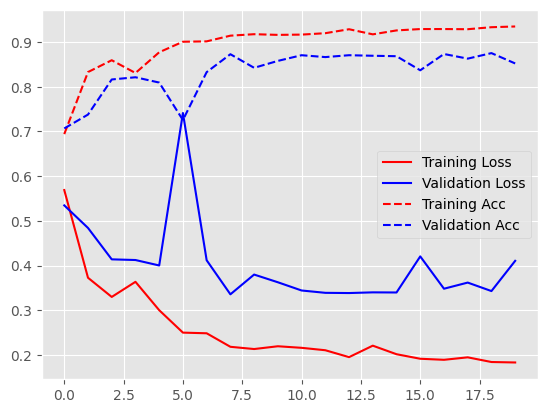

In [57]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'],c="b")
plt.plot(history.history['accuracy'],c="r",linestyle="--")
plt.plot(history.history['val_accuracy'],c="b",linestyle="--")
plt.legend(['Training Loss','Validation Loss','Training Acc','Validation Acc'])
plt.show()

#*Dot-Product Attention Layer*

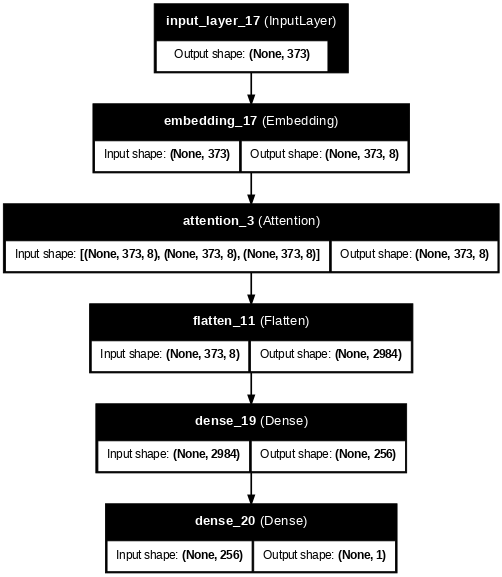

In [60]:
from keras.layers import Flatten, Activation, RepeatVector, Permute, Multiply, Lambda, Dense

# Same approach as before, but we will just use layers.Attention() to implement the steps.

inputs = keras.layers.Input(shape=[373,]) # We take the sequence of intger encodings as input.

embeds = keras.layers.Embedding(input_dim=20000,output_dim=8)(inputs) # Map integers to 8-dimensional vectors.

attention_output = keras.layers.Attention()([embeds,embeds,embeds])

flatten = layers.Flatten()(attention_output)

hidden = keras.layers.Dense(256, activation="sigmoid")(flatten)

outputs = keras.layers.Dense(1, activation="sigmoid")(hidden)

model = keras.Model(inputs,outputs)
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model,show_shapes=True,dpi=60,show_layer_names=True)

How big is the resuting network? The same size! This Attention() layer is just a wrapper for the operations we implemented above.

In [61]:
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 373)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 373, 8)    │    160,000 │ input_layer_17[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 373, 8)    │          0 │ embedding_17[0][… │
│ (Attention)         │                   │            │ embedding_17[0][… │
│                     │                   │            │ embedding_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 2984)      │          0 │ attention_3[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │    764,160 │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1)         │        257 │ dense_19[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 924,417 (3.53 MB)

 Trainable params: 924,417 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

#*QKV Framework Attention Layer*

We can leverage layers.MultiHeadAttention() to implement a QKV attention layer with weight matrices per Q, K and V.

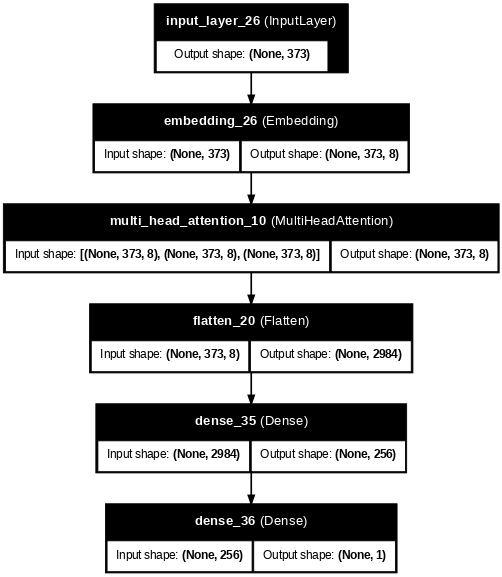

In [81]:
from keras.layers import Flatten, Dense

inputs = keras.layers.Input(shape=(373,)) # We again take the sequence of integer encodings as input.

# Map 20,000 integer indices to 8-dimensional embedding space
embeddings = keras.layers.Embedding(input_dim=20_000,output_dim=8)(inputs)

# We implement self-attention here; the input serves as the query, the key (comparison), and is also the value against which attention scores are applied.
attention_weighted_embeddings = keras.layers.MultiHeadAttention(num_heads=4,key_dim=8,value_dim=8,)(query=embeddings,key=embeddings,value=embeddings)

flatten = layers.Flatten()(attention_weighted_embeddings)

hidden = keras.layers.Dense(256, activation="sigmoid")(flatten)

outputs = keras.layers.Dense(1, activation="sigmoid")(hidden)

model = keras.Model(inputs,outputs)
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model,show_shapes=True,dpi=60,show_layer_names=True)

Now how many parameters does our model have? A slight increase of about 1,000 additional weights (our Q, K, V weight matrices). Since each embedded word is an 1 x 8 vector, these weight matrices are going to be (8 x 8) matrices in each case. (1 x 8) x (8 x 8) = (1 x 8) again. That means 64 weights per matrix, 3 matrices = 192 weights, x 4 heads = 768 additional weights. Another 256 weights come from W_o, a 4th weight matrix, which projects the results back to the same dimensionality as the original input (in case you happen to choose K,V dimensions that differ from the input embeddings. And, the remaining weights are the bias terms (8 per weight matrix in this case, and 8 in W_o).

In [82]:
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 373)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_26        │ (None, 373, 8)    │    160,000 │ input_layer_26[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 373, 8)    │      1,128 │ embedding_26[0][… │
│ (MultiHeadAttentio… │                   │            │ embedding_26[0][… │
│                     │                   │            │ embedding_26[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 2984)      │          0 │ multi_head_atten… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 256)       │    764,160 │ flatten_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 1)         │        257 │ dense_35[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 925,545 (3.53 MB)

 Trainable params: 925,545 (3.53 MB)

 Non-trainable params: 0 (0.00 B)

Now we fit our model. We pass 90% accuracy pretty quickly!

In [83]:
callbacks = [
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/Teaching/Courses/BA 510/Course Material/Week 8/qkv_attention.keras",
                                    save_best_only=True)
]

history = model.fit(processed_text, label,
                        validation_split=0.2,
                        epochs=3, batch_size=32,callbacks=callbacks)

Epoch 1/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7768 - loss: 0.4140 - val_accuracy: 0.8582 - val_loss: 0.3011
Epoch 2/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9281 - loss: 0.1735 - val_accuracy: 0.9008 - val_loss: 0.2346
Epoch 3/3
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9469 - loss: 0.1303 - val_accuracy: 0.8953 - val_loss: 0.2425


And plotting loss over training, we end up close to 90% accuracy on the validation sample.

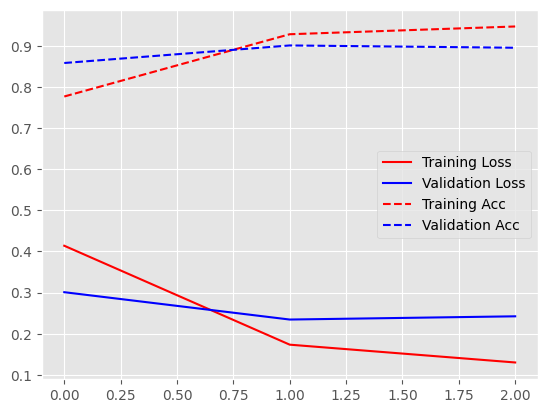

In [84]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'],c="b")
plt.plot(history.history['accuracy'],c="r",linestyle="--")
plt.plot(history.history['val_accuracy'],c="b",linestyle="--")
plt.legend(['Training Loss','Validation Loss','Training Acc','Validation Acc'])
plt.show()